In [49]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(str(Path("..").resolve()))

# Load trained models with different seeds


In [50]:
from helpers import load_fitted_model

model_configurations = [
    ("hmm", 2, 42),
    ("hmm", 3, 42),
    ("hmm", 4, 42),  # Configurations with seed 42
    ("vdhmm", 2, 42),
    ("vdhmm", 3, 42),
    ("vdhmm", 4, 42),
    ("hmm", 2, 43),
    ("hmm", 3, 43),
    ("hmm", 4, 43),
    ("vdhmm", 2, 43),
    ("vdhmm", 3, 43),  # Configurations with seed 43
    ("vdhmm", 4, 43),
    ("hmm", 2, 123),
    ("hmm", 3, 123),
    ("hmm", 4, 123),  # Configurations with seed 123
    ("vdhmm", 2, 123),
    ("vdhmm", 3, 123),
    ("vdhmm", 4, 123),
    ("hmm", 2, None),  # Configuration with seed None (original indices)
    ("hmm", 3, None),
    ("hmm", 4, None),
    ("vdhmm", 2, None),  # Configuration with seed None (original indices)
    ("vdhmm", 3, None),
    ("vdhmm", 4, None),
]

n_models = len(model_configurations)

# get AUC and R_HAT metrics out of hmm models
results_df = pd.DataFrame(
    {
        "Model": [
            f"{model_name}_{S}" for (model_name, S, seed) in model_configurations
        ],
        "Seed": [
            seed if seed else "Original"
            for (model_name, S, seed) in model_configurations
        ],
        "AUC_TRAIN": [0.0] * n_models,
        "AUC_TEST": [0.0] * n_models,
        "R_HAT_MEAN": [0.0] * n_models,
        "R_HAT_STD": [0.0] * n_models,
    }
)

In [51]:
import arviz as az
from sklearn.metrics import roc_auc_score

from constants import PROCESSED_DATA_FOLDER
from helpers import ModelData

# Loop over all model configurations
for k, (model_name, S, seed) in enumerate(model_configurations):
    print(f"Processing {k+1}/{n_models}: {model_name} with {S} states (seed={seed})...")
    model_data = ModelData.from_pickle(
        PROCESSED_DATA_FOLDER / f"processed_data_{seed if seed else 'original'}.pkl"
    )
    eval_indices = model_data.eval_indices

    # Load the fitted model with the given seed
    try:
        model = load_fitted_model(model_name, S, seed=seed)
    except FileNotFoundError:
        print(
            f"FileNotFound: {model_name} with {S} states and seed {seed} was not found! Skipping..."
        )
        continue

    log_lik = model.fit.stan_variable("log_lik")
    log_lik_test = model.fit.stan_variable("log_lik_test")
    close_prob = model.fit.stan_variable("close_prob")
    close_prob_mean = close_prob.mean(axis=0)

    idata = az.from_cmdstanpy(model.fit, log_likelihood="log_lik")

    # Calculate AUC for training data (as percentage)
    y_true_train = np.array(model.stan_data["Closed"][:500])
    results_df.loc[k, "AUC_TRAIN"] = 100 * roc_auc_score(
        y_true_train, close_prob_mean[:500]
    )

    y_true_test = np.array(model.stan_data["Closed"])[eval_indices]

    # Take the mean for all businesses across all iterations
    close_prob_test_mean = np.mean(model.fit.stan_variable("close_prob"), axis=0)
    results_df.loc[k, "AUC_TEST"] = 100 * roc_auc_score(
        y_true_test, close_prob_mean[eval_indices]
    )

    # Use the already stored summary DataFrame (model.summary)
    # Calculate mean and std of R_hat across all parameters
    results_df.loc[k, "R_HAT_MEAN"] = np.nanmean(model.summary["R_hat"])
    results_df.loc[k, "R_HAT_STD"] = np.nanstd(model.summary["R_hat"])

print("\nResults:")

# Round results
results_df["AUC_TRAIN"] = results_df["AUC_TRAIN"].round(2)
results_df["AUC_TEST"] = results_df["AUC_TEST"].round(2)
results_df["R_HAT_MEAN"] = results_df["R_HAT_MEAN"].round(4)
results_df["R_HAT_STD"] = results_df["R_HAT_STD"].round(4)

np.random.seed(None)

results_df

Processing 1/24: hmm with 2 states (seed=42)...
Processing 2/24: hmm with 3 states (seed=42)...
Processing 3/24: hmm with 4 states (seed=42)...
FileNotFound: hmm with 4 states and seed 42 was not found! Skipping...
Processing 4/24: vdhmm with 2 states (seed=42)...
Processing 5/24: vdhmm with 3 states (seed=42)...
Processing 6/24: vdhmm with 4 states (seed=42)...
FileNotFound: vdhmm with 4 states and seed 42 was not found! Skipping...
Processing 7/24: hmm with 2 states (seed=43)...
Processing 8/24: hmm with 3 states (seed=43)...
Processing 9/24: hmm with 4 states (seed=43)...
Processing 10/24: vdhmm with 2 states (seed=43)...
Processing 11/24: vdhmm with 3 states (seed=43)...
Processing 12/24: vdhmm with 4 states (seed=43)...
Processing 13/24: hmm with 2 states (seed=123)...
Processing 14/24: hmm with 3 states (seed=123)...
Processing 15/24: hmm with 4 states (seed=123)...
Processing 16/24: vdhmm with 2 states (seed=123)...
Processing 17/24: vdhmm with 3 states (seed=123)...
Processing 

,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,hmm_2,42,79.88,78.53,1.0036,0.0032
1,hmm_3,42,83.58,80.73,1.0019,0.0015
2,hmm_4,42,0.00,0.00,0.0000,0.0000
3,vdhmm_2,42,79.49,78.52,1.0008,0.0008
4,vdhmm_3,42,85.38,82.68,1.0058,0.0058
5,vdhmm_4,42,0.00,0.00,0.0000,0.0000
6,hmm_2,43,82.25,73.58,1.0007,0.0009
7,hmm_3,43,84.49,78.92,1.0011,0.0010
8,hmm_4,43,85.50,79.40,1.1365,0.2112
9,vdhmm_2,43,82.79,71.25,1.0361,0.0355


In [52]:
# Split results for different seeds
grouped_dfs = {}

for seed, group_df in results_df.groupby("Seed"):
    grouped_dfs[seed] = group_df.copy()

print("\n" + "=" * 60)
print("SEED 42:")
print(60 * "=")
display(grouped_dfs[42])


print("\n" + "=" * 60)
print("SEED 43:")
print(60 * "=")
display(grouped_dfs[43])


print("\n" + "=" * 60)
print("SEED 123:")
print(60 * "=")
display(grouped_dfs[123])

print("\n" + "=" * 60)
print("ORIGINAL INDICES")
print(60 * "=")
display(grouped_dfs["Original"])


SEED 42:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
0,hmm_2,42,79.88,78.53,1.0036,0.0032
1,hmm_3,42,83.58,80.73,1.0019,0.0015
2,hmm_4,42,0.00,0.00,0.0000,0.0000
3,vdhmm_2,42,79.49,78.52,1.0008,0.0008
4,vdhmm_3,42,85.38,82.68,1.0058,0.0058
5,vdhmm_4,42,0.00,0.00,0.0000,0.0000



SEED 43:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
6,hmm_2,43,82.25,73.58,1.0007,0.0009
7,hmm_3,43,84.49,78.92,1.0011,0.0010
8,hmm_4,43,85.50,79.40,1.1365,0.2112
9,vdhmm_2,43,82.79,71.25,1.0361,0.0355
10,vdhmm_3,43,86.15,81.20,1.0006,0.0007
11,vdhmm_4,43,86.83,80.63,1.0007,0.0007



SEED 123:


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
12,hmm_2,123,78.60,77.52,1.0010,0.0007
13,hmm_3,123,82.51,81.64,1.0008,0.0007
14,hmm_4,123,82.92,82.82,1.1322,0.2121
15,vdhmm_2,123,78.19,77.61,1.0007,0.0008
16,vdhmm_3,123,84.41,83.59,1.0009,0.0008
17,vdhmm_4,123,83.94,83.98,1.0009,0.0010



ORIGINAL INDICES


,Model,Seed,AUC_TRAIN,AUC_TEST,R_HAT_MEAN,R_HAT_STD
18,hmm_2,Original,78.49,77.27,1.0010,0.0011
19,hmm_3,Original,81.83,82.67,1.0418,0.0418
20,hmm_4,Original,82.45,83.62,1.0007,0.0011
21,vdhmm_2,Original,78.46,76.84,1.0012,0.0014
22,vdhmm_3,Original,83.92,84.40,1.0008,0.0012
23,vdhmm_4,Original,83.24,84.77,1.0014,0.0017


# Robustness Analysis: Seed Variability

---

## Statistische Analyse der Model-Robustheit

Analyse der Performance-Stabilität der HMM und VDHMM Modelle über verschiedene Seeds hinweg


In [53]:
# Teile Modellname (HMM_2) in Modeltyp (HMM) und Anzahl Zustände (2)
results_df["Model_Type"] = results_df["Model"].str.split("_").str[0].str.upper()
results_df["States"] = results_df["Model"].str.split("_").str[1].astype(int)


print("=" * 110)
print("HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)")
print("=" * 110)
print(
    results_df[
        ["Model_Type", "States", "Seed", "AUC_TRAIN", "AUC_TEST", "R_HAT_MEAN"]
    ].to_string(index=False)
)

# Berechne Statistiken pro Modellkonfiguration
robustness_stats = (
    results_df.groupby(["Model_Type", "States"])
    .agg(
        {
            "AUC_TEST": ["mean", "std", "min", "max"],
            "AUC_TRAIN": ["mean", "std"],
            "R_HAT_MEAN": ["mean", "max"],
        }
    )
    .round(2)
)

# Flatten multi-level columns
robustness_stats.columns = [
    "_".join(col).strip() for col in robustness_stats.columns.values
]
robustness_stats = robustness_stats.reset_index()

# Berechne Coefficient of Variation (CV) für AUC_TEST in Prozent
robustness_stats["AUC_TEST_CV_%"] = (
    robustness_stats["AUC_TEST_std"] / robustness_stats["AUC_TEST_mean"] * 100
).round(2)

# Berechne Range für AUC_TEST
robustness_stats["AUC_TEST_Range"] = (
    robustness_stats["AUC_TEST_max"] - robustness_stats["AUC_TEST_min"]
).round(2)

print("\n" + "=" * 110)
print("ROBUSTNESS STATISTICS: Mean ± Std across Seeds")
print("=" * 110)
print(robustness_stats.to_string(index=False))

# Identifiziere die robustesten Modelle (niedrigster CV%)
print("\n" + "=" * 110)
print("ROBUSTNESS RANKING (by Coefficient of Variation)")
print("=" * 110)
robustness_ranking = robustness_stats.sort_values("AUC_TEST_CV_%")
print(
    robustness_ranking[
        [
            "Model_Type",
            "States",
            "AUC_TEST_mean",
            "AUC_TEST_std",
            "AUC_TEST_CV_%",
            "AUC_TEST_Range",
        ]
    ].to_string(index=False)
)

HMM ROBUSTNESS DATA (All Seeds: 42, 43, 123)
Model_Type  States     Seed  AUC_TRAIN  AUC_TEST  R_HAT_MEAN
       HMM       2       42      79.88     78.53      1.0036
       HMM       3       42      83.58     80.73      1.0019
       HMM       4       42       0.00      0.00      0.0000
     VDHMM       2       42      79.49     78.52      1.0008
     VDHMM       3       42      85.38     82.68      1.0058
     VDHMM       4       42       0.00      0.00      0.0000
       HMM       2       43      82.25     73.58      1.0007
       HMM       3       43      84.49     78.92      1.0011
       HMM       4       43      85.50     79.40      1.1365
     VDHMM       2       43      82.79     71.25      1.0361
     VDHMM       3       43      86.15     81.20      1.0006
     VDHMM       4       43      86.83     80.63      1.0007
       HMM       2      123      78.60     77.52      1.0010
       HMM       3      123      82.51     81.64      1.0008
       HMM       4      123      82.92  

## Visualisierung: Seed Variability


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setze Seaborn Style
sns.set_style("whitegrid")

### 2. Mean AUC Test with Standard Deviation (Error Bars)

**Interpretation:**

- Bars show the mean AUC across all seeds
- Error bars show the standard deviation
- Smaller error bars = higher robustness


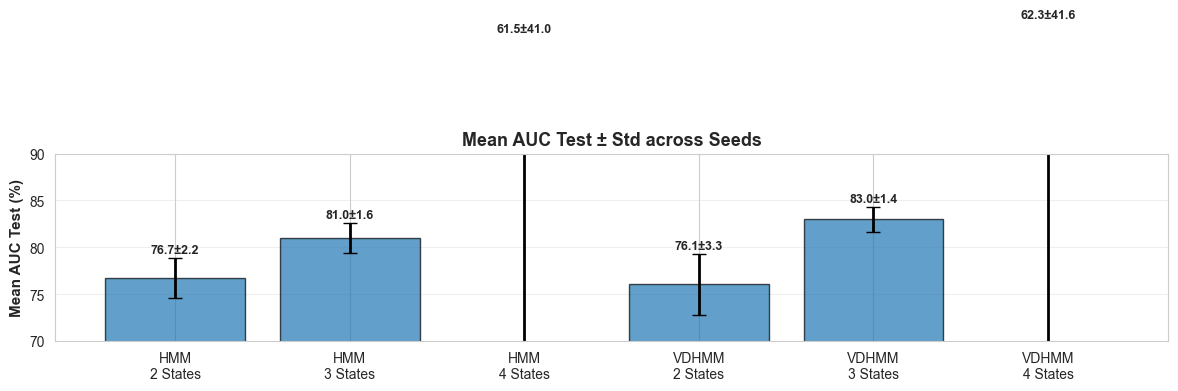

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(robustness_stats))

bars = ax.bar(
    x_pos,
    robustness_stats["AUC_TEST_mean"],
    yerr=robustness_stats["AUC_TEST_std"],
    alpha=0.7,
    edgecolor="black",
    capsize=5,
    error_kw={"linewidth": 2},
)

ax.set_ylabel("Mean AUC Test (%)", fontsize=11, fontweight="bold")
ax.set_title("Mean AUC Test ± Std across Seeds", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [
        f"{row['Model_Type']}\n{row['States']} States"
        for _, row in robustness_stats.iterrows()
    ],
    fontsize=10,
)
ax.set_ylim([70, 90])
ax.grid(axis="y", alpha=0.3)

# Values above bars
for i, (mean, std) in enumerate(
    zip(robustness_stats["AUC_TEST_mean"], robustness_stats["AUC_TEST_std"])
):
    ax.text(
        i,
        mean + std + 0.5,
        f"{mean:.1f}±{std:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

### 3. Coefficient of Variation (CV%) - Robustness Ranking

**Interpretation:**

- Coefficient of Variation (CV%) = Standard Deviation / Mean × 100
- Lower CV% = more robust model (less relative variability)
- CV% < 3% is considered very robust (which would mean a difference of ±2.5%)


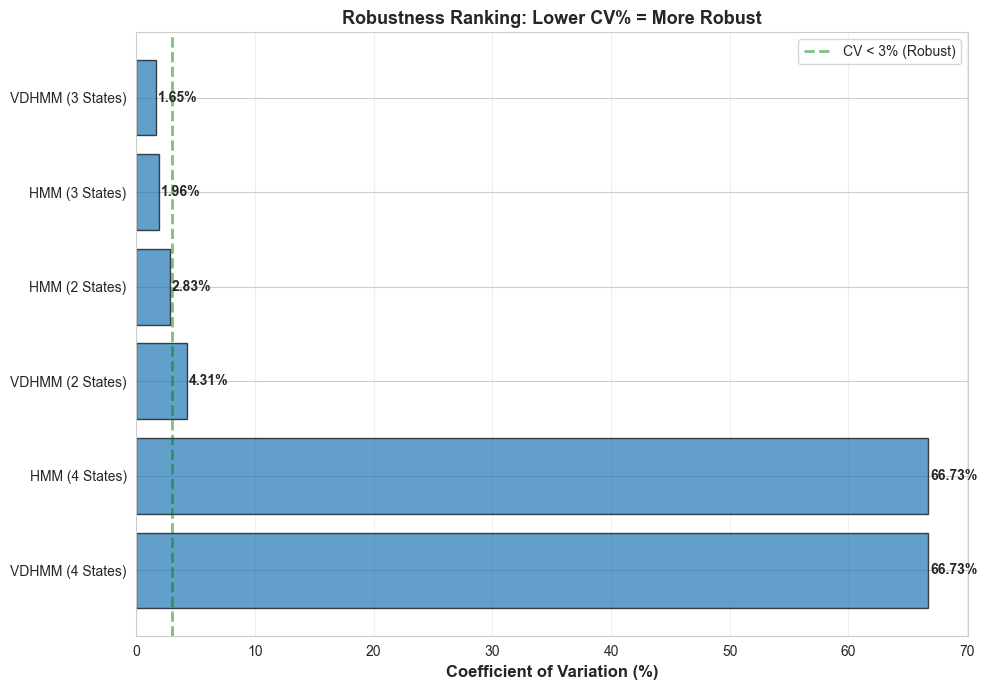

In [56]:
fig, ax = plt.subplots(figsize=(10, 7))

cv_sorted = robustness_stats.sort_values("AUC_TEST_CV_%")
x_pos = np.arange(len(cv_sorted))

bars = ax.barh(x_pos, cv_sorted["AUC_TEST_CV_%"], alpha=0.7, edgecolor="black")

ax.set_xlabel("Coefficient of Variation (%)", fontsize=12, fontweight="bold")
ax.set_title(
    "Robustness Ranking: Lower CV% = More Robust", fontsize=13, fontweight="bold"
)
ax.set_yticks(x_pos)
ax.set_yticklabels(
    [
        f"{row['Model_Type']} ({row['States']} States)"
        for _, row in cv_sorted.iterrows()
    ],
    fontsize=10,
)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

# Values next to bars
for i, cv in enumerate(cv_sorted["AUC_TEST_CV_%"]):
    ax.text(cv + 0.15, i, f"{cv:.2f}%", va="center", fontsize=10, fontweight="bold")

# Mark highly robust models (CV < 3%)
ax.axvline(
    x=3,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label="CV < 3% (Robust)",
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 4. Heatmap: Model × Seed Performance Matrix

**Interpretation:**

- Green cells = high performance, yellow = medium, red = low performance
- Consistent colors across seeds = robust models
- VDHMM (3/4 States) shows consistently green values (>80% AUC)
- HMM (2 States) with Seed 43 and VDHMM (2 States) with Seed 43 show weaknesses (~72-74% AUC)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

# Pivot table for heatmap
pivot_data = results_df.pivot_table(
    values="AUC_TEST", index=["Model_Type", "States"], columns="Seed"
)

# Create labels
row_labels = [f"{mt} ({s} States)" for mt, s in pivot_data.index]

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=79,
    vmin=72,
    vmax=84,
    cbar_kws={"label": "AUC Test (%)"},
    yticklabels=row_labels,
    ax=ax,
    linewidths=1,
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)

ax.set_xlabel("Seed", fontsize=12, fontweight="bold")
ax.set_ylabel("Model Configuration", fontsize=12, fontweight="bold")
ax.set_title(
    "AUC Test Performance Heatmap: Model × Seed", fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# Robustness summary
print("=" * 100)
print("ROBUSTNESS SUMMARY: Top 3 Most Robust Models")
print("=" * 100)

top3_robust = robustness_ranking.head(3)

for i, (idx, row) in enumerate(top3_robust.iterrows(), 1):
    print(f"\n{i}. {row['Model_Type']} ({row['States']} States)")
    print(f"   - Mean AUC Test: {row['AUC_TEST_mean']:.2f}%")
    print(f"   - Std: ±{row['AUC_TEST_std']:.2f}%")
    print(f"   - Coefficient of Variation (CV): {row['AUC_TEST_CV_%']:.2f}%")
    print(
        f"   - Range: {row['AUC_TEST_Range']:.2f}% (Min: {row['AUC_TEST_min']:.2f}%, Max: {row['AUC_TEST_max']:.2f}%)"
    )
    print(
        f"   - Mean R-hat: {row['R_HAT_MEAN_mean']:.4f} (Max: {row['R_HAT_MEAN_max']:.4f})"
    )